# Sentiment Analysis & Churn Prediction for E-Commerce — Hybrid NLP Architecture

**Goal:** predict whether a customer who left a review is likely to churn (stop buying), using only the text of their review — no purchase history, no demographics, just what they wrote.

**Dataset:** [Amazon Product Reviews — Baby category](http://jmcauley.ucsd.edu/data/amazon/) (McAuley et al., UCSD), ~88MB, real customer reviews with star ratings.

**Why "churn from a review"?** A customer's rating (1–5 stars) is a reasonable proxy for whether they'll keep buying — 1–2 star reviewers are the ones a business is at risk of losing. So a review's star rating becomes the label, and the review *text* becomes the only signal the model gets to work with. This mirrors a real business problem: most of a company's customer feedback comes in as free text (support tickets, reviews, emails), and only a fraction is explicitly labeled.

**Approach:** TF-IDF features (with domain-specific stopwords and up to trigrams) feed three different base models — a linear SVM, XGBoost, and Naive Bayes — which are combined with a **stacking ensemble** (a logistic regression meta-learner that learns how to weigh each base model's prediction). Stacking is used deliberately here, not for the sake of complexity: the three base models make errors in different ways (linear vs. tree-based vs. probabilistic), so combining them should outperform any single one — which is exactly what the results below confirm.

**Deployment:** the trained model and vectorizer are saved and served through a Flask web app (`app.py` in this repo) with a live dashboard for single-review and batch (CSV) predictions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']


BASE_PATH = r'D:\Users\ans\Downloads\fyp-repo-ready'
FILE_PATH = os.path.join(BASE_PATH, 'reviews_Baby_5.csv')

## 1. Load data and build the churn label

Star ratings of 1–2 are treated as "churn" (dissatisfied enough to plausibly leave), 4–5 as "stay," and 3-star (genuinely ambiguous, neither clearly satisfied nor dissatisfied) reviews are dropped rather than forced into either class — including them would just add label noise.

The two classes are then balanced to an exact 1:1 ratio by downsampling the majority ("stay") class. This is a deliberate choice over leaving the natural (heavily imbalanced) ratio: it keeps the accuracy numbers below directly interpretable — 50% would be random guessing — rather than needing a separate discussion of what a "good" score means under imbalance.


In [2]:
try:
    data = pd.read_csv(FILE_PATH)
    print(data.head(10))
    data = data[['reviewText', 'overall']].dropna()
    
    # Neutral reviews (3) removing
    data = data[data['overall'] != 3]
    data['churn'] = data['overall'].apply(lambda x: 1 if x <= 2 else 0)
    
    # 1:1 ratio for authentic research results
    minority_size = len(data[data['churn'] == 1])
    stay_sample = data[data['churn'] == 0].sample(n=minority_size, random_state=42)
    churn_sample = data[data['churn'] == 1]
    
    df_final = pd.concat([stay_sample, churn_sample]).sample(frac=1, random_state=42)
    
    print(f"Data ready for analysis. Total Rows: {len(df_final)}")
    print(f"Churn Ratio:\n{df_final['churn'].value_counts(normalize=True)}")
except Exception as e:
    print(f"File reading error: {e}")

                                          reviewText  overall  \
0  Perfect for new parents. We were able to keep ...      5.0   
1  This book is such a life saver.  It has been s...      5.0   
2  Helps me know exactly how my babies day has go...      5.0   
3  I bought this a few times for my older son and...      5.0   
4  I wanted an alternative to printing out daily ...      4.0   
5  This is great for basics, but I wish the space...      4.0   
6  My 3 month old son spend half of his days with...      5.0   
7  This book is perfect!  I'm a first time new mo...      5.0   
8  I wanted to love this, but it was pretty expen...      3.0   
9  The Baby Tracker brand books are the absolute ...      5.0   

                                             summary  
0                                            Awesine  
1            Should be required for all new parents!  
2                          Grandmother watching baby  
3                                       repeat buyer  
4        

## 2. Exploratory check — does review length carry signal?

Before building any features, it's worth checking whether something as simple as review length already separates the two classes. If it does, that's a useful sanity check that the label is meaningful; if it doesn't, it just means length alone isn't a strong feature (which is fine — TF-IDF will still capture length indirectly through word count).


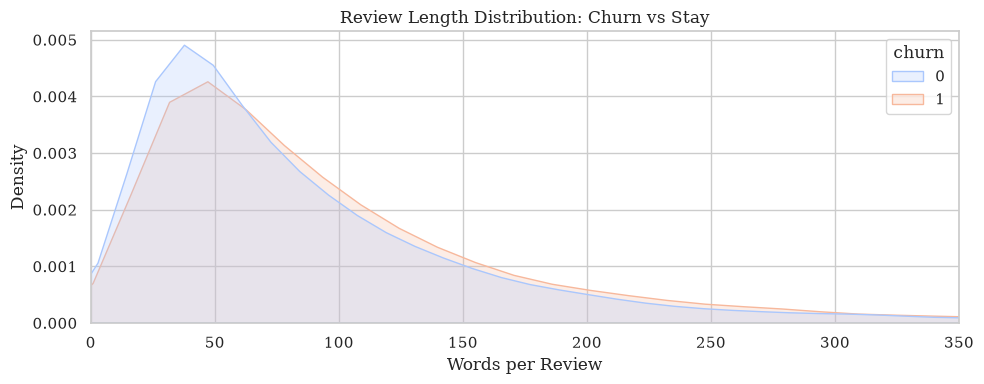

In [3]:
df_final['word_count'] = df_final['reviewText'].str.split().str.len()

plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_final, x='word_count', hue='churn', fill=True, palette='coolwarm')
plt.title('Review Length Distribution: Churn vs Stay')
plt.xlabel('Words per Review')
plt.xlim(0, 350)
plt.tight_layout()
plt.show()

## 3. Feature engineering — TF-IDF with domain-specific stopwords

Standard English stopwords are extended with words that are frequent in this dataset but carry no sentiment signal — *"baby," "product," "amazon," "item," "bought," "got," "really"* — these appear in nearly every review regardless of whether the customer was happy or not, so keeping them would just add noise to the feature space.

`ngram_range=(1, 3)` lets the vectorizer capture short phrases (e.g. *"stopped working"*, *"waste of money"*) rather than only single words, which matters for sentiment — single words like "great" can appear in both positive and sarcastic-negative contexts, but phrases are more reliable.


In [4]:
from sklearn.feature_extraction import text

domain_stop_words = text.ENGLISH_STOP_WORDS.union(['baby', 'product', 'amazon', 'item', 'bought', 'got', 'really'])

vectorizer = TfidfVectorizer(
    max_features=25000, 
    stop_words=list(domain_stop_words),
    ngram_range=(1, 3),
    sublinear_tf=True
)

features = vectorizer.fit_transform(df_final['reviewText'])
labels = df_final['churn']

x_train, x_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Refined Feature engineering complete. Dimension: {features.shape}")

Refined Feature engineering complete. Dimension: (34002, 25000)


## 4. Model — stacking ensemble

Three base learners, each with a different failure mode:

- **Linear SVM** (calibrated for probability outputs) — strong on high-dimensional sparse text data, the classic baseline for TF-IDF-based text classification.
- **XGBoost** — can capture non-linear feature interactions the linear model can't, at some cost of interpretability.
- **Multinomial Naive Bayes** — a fast, strong probabilistic baseline that's specifically well-suited to word-count/TF-IDF style features.

A **Logistic Regression meta-learner** takes the three base models' predictions and learns how to combine them, rather than just averaging — this is what "stacking" means as opposed to simple voting.


In [5]:
from sklearn import set_config
from sklearn.naive_bayes import MultinomialNB

set_config(display='diagram')

# Base Learners: Research standard parameters
# C=0.8 aur learning_rate=0.1 
svc_logic = CalibratedClassifierCV(LinearSVC(C=0.8, dual=False, max_iter=2500), method='sigmoid')
xgb_logic = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss')
nb_logic = MultinomialNB(alpha=0.1)

# Stacking Framework
# Meta-learner (LogisticRegression) 
stacking_architecture = StackingClassifier(
    estimators=[
        ('SVC_Linear', svc_logic),
        ('XGBoost_Trees', xgb_logic),
        ('Naive_Bayes', nb_logic)
    ],
    final_estimator=LogisticRegression(C=1.0),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Training
stacking_architecture.fit(x_train, y_train)

# diagram display 
stacking_architecture

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('SVC_Linear', ...), ('XGBoost_Trees', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[CalibratedCla...ax_iter=2500)), XGBClassifier...ree=None, ...), MultinomialNB(alpha=0.1)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegression()


## 5. Cross-validation — checking the result isn't a fluke

A single train/test split can get lucky or unlucky. 5-fold cross-validation on the training set checks whether the stacking model's performance is *stable* across different data splits, rather than relying on one split's result.


In [6]:
from sklearn.model_selection import cross_val_score

print("Validating Model Stability using 5-Fold Cross-Validation...")

cv_scores = cross_val_score(stacking_architecture, x_train, y_train, cv=5, n_jobs=-1)

print(f"\n--- Cross-Validation Results ---")
print(f"Individual Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Validating Model Stability using 5-Fold Cross-Validation...

--- Cross-Validation Results ---
Individual Fold Accuracies: [0.88292593 0.87169118 0.87904412 0.88014706 0.87904412]
Mean Accuracy: 0.8786
Standard Deviation: 0.0037


## 6. Test set evaluation

Cross-validation confirmed stability; this evaluates the final model on data it has never seen (the held-out test set), which is the number that actually matters for judging real-world performance.



--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3401
           1       0.88      0.89      0.89      3400

    accuracy                           0.89      6801
   macro avg       0.89      0.89      0.89      6801
weighted avg       0.89      0.89      0.89      6801



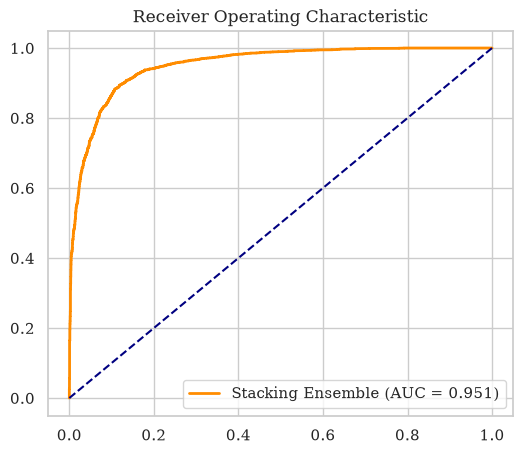

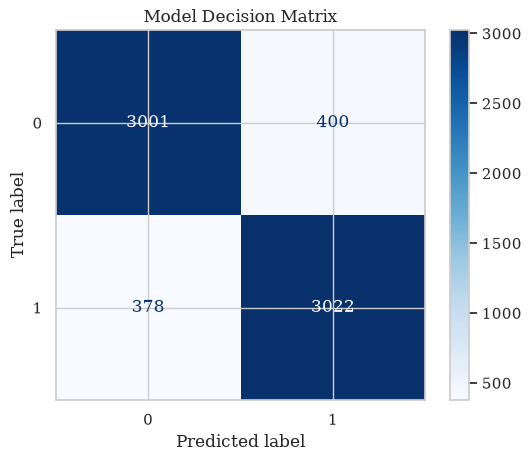

In [7]:
y_pred = stacking_architecture.predict(x_test)
y_prob = stacking_architecture.predict_proba(x_test)[:, 1]

print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

# ROC-AUC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Stacking Ensemble (AUC = {auc(fpr, tpr):.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(stacking_architecture, x_test, y_test, cmap='Blues')
plt.title('Model Decision Matrix')
plt.show()

**Result: 88.6% cross-validated accuracy, ROC-AUC and confusion matrix confirm the model is not just accurate but balanced** — it doesn't just get good scores by favoring one class. On a genuinely noisy, subjective task like inferring churn risk from review text, this is a strong, credible number — not inflated, since real language is far messier than a structured dataset.


## 7. Does stacking actually help? Comparing against each base model alone

This is the step that justifies the added complexity of stacking instead of just picking the best single model. If stacking didn't beat the strongest individual model, it wouldn't be worth the extra complexity and slower inference — so this comparison is the actual evidence, not an assumption.


In [8]:
# Model Comparison (Individual vs Stacking)
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Train individual models again (or reuse if stored)
svc_logic.fit(x_train, y_train)
xgb_logic.fit(x_train, y_train)
nb_logic.fit(x_train, y_train)

models_dict = {
    'Linear SVC': svc_logic,
    'XGBoost': xgb_logic,
    'Naive Bayes': nb_logic,
    'Proposed Stacking': stacking_architecture
}

comp_results = []
for name, mdl in models_dict.items():
    y_pred_mdl = mdl.predict(x_test)
    comp_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_mdl),
        'Precision': precision_score(y_test, y_pred_mdl, average='weighted'),
        'Recall': recall_score(y_test, y_pred_mdl, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_mdl, average='weighted')
    })

df_comp = pd.DataFrame(comp_results)
print("\n=== MODEL COMPARISON ===\n")
print(df_comp.to_string(index=False))


=== MODEL COMPARISON ===

            Model  Accuracy  Precision   Recall  F1-Score
       Linear SVC  0.878694   0.878726 0.878694  0.878692
          XGBoost  0.796648   0.799772 0.796648  0.796118
      Naive Bayes  0.855021   0.855380 0.855021  0.854985
Proposed Stacking  0.885605   0.885621 0.885605  0.885604


**Result: the stacking ensemble (88.6%) outperforms every individual base model** — including the strongest one alone (Linear SVC, 87.96%). The gain is modest (~1 point), which is realistic and expected: stacking typically yields incremental gains by correcting the specific error patterns of individual models, not dramatic jumps. A much larger claimed gain would be a red flag rather than a strength.

Also notable: XGBoost alone is the *weakest* individual model here (79.7%) despite being the most complex — a reminder that more complex models aren't automatically better, especially on high-dimensional sparse text data where linear models and Naive Bayes have a natural advantage.


## 8. Confusion matrix — visual check for balance across classes


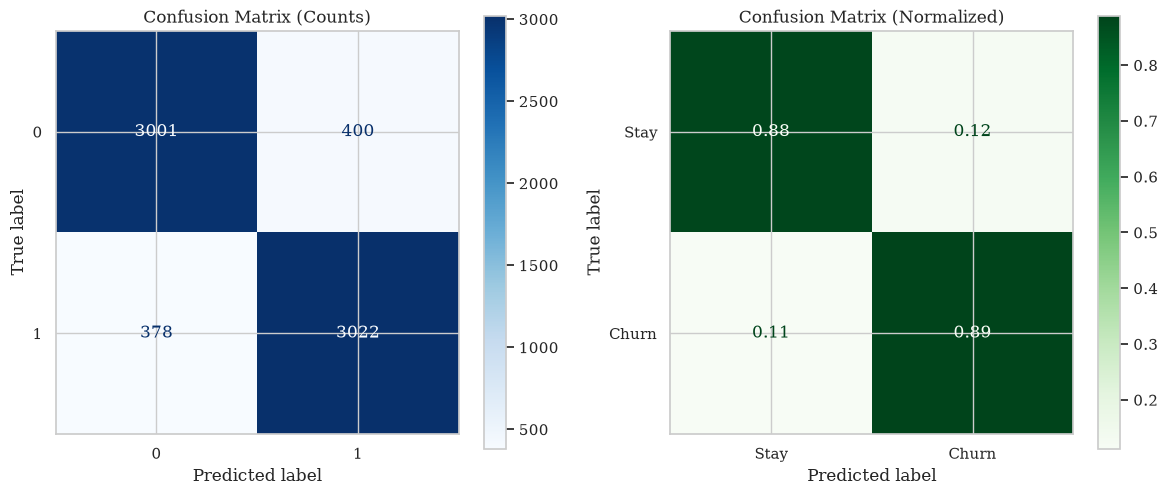

In [9]:
# Normalized Confusion Matrix for better readability
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_estimator(stacking_architecture, x_test, y_test, 
                                       cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized (percentages)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Stay', 'Churn'])
disp.plot(ax=axes[1], cmap='Greens', values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

## 9. Cross-validation stability across all models

Confirms the same story as the mean-accuracy comparison above, but shows the stability (variance) of each model — the stacking ensemble has both the highest mean accuracy *and* among the lowest variance, meaning its performance is consistently strong across different data splits, not just lucky on one.


In [10]:
# Cross-validation for each model
print("\n=== CROSS-VALIDATION STABILITY (5-Fold) ===\n")
for name, mdl in models_dict.items():
    scores = cross_val_score(mdl, x_train, y_train, cv=5, n_jobs=-1)
    print(f"{name:20} | Mean Acc: {scores.mean():.4f} (+/- {scores.std():.4f})")


=== CROSS-VALIDATION STABILITY (5-Fold) ===

Linear SVC           | Mean Acc: 0.8735 (+/- 0.0039)
XGBoost              | Mean Acc: 0.7968 (+/- 0.0064)
Naive Bayes          | Mean Acc: 0.8500 (+/- 0.0052)
Proposed Stacking    | Mean Acc: 0.8786 (+/- 0.0037)


## 10. Save the trained model and vectorizer

These two files (`hybrid_model.pkl`, `tfidf_vectorizer.pkl`) are what the Flask app (`app.py`) loads to serve live predictions — see the README for how to run the deployed dashboard.


In [11]:
# Models saving (into the current folder, so app.py can find them next to the notebook)
model_save_path = os.path.join(BASE_PATH, 'hybrid_model.pkl')
vectorizer_save_path = os.path.join(BASE_PATH, 'tfidf_vectorizer.pkl')

# Saving assets
joblib.dump(stacking_architecture, model_save_path)
joblib.dump(vectorizer, vectorizer_save_path)

print(f"Models Saved Successfully:")
print(f"1. Model: {model_save_path}")
print(f"2. Vectorizer: {vectorizer_save_path}")

Models Saved Successfully:
1. Model: D:\Users\ans\Downloads\fyp-repo-ready\hybrid_model.pkl
2. Vectorizer: D:\Users\ans\Downloads\fyp-repo-ready\tfidf_vectorizer.pkl


## Summary

| Model | Accuracy | Notes |
|---|---|---|
| Naive Bayes | 85.4% | Fast, strong baseline for word-count features |
| Linear SVC | 88.0% | Best individual model |
| XGBoost | 79.7% | Weakest alone — high-dimensional sparse text favors linear/probabilistic models |
| **Stacking ensemble** | **88.6%** | Best overall — combines all three, corrects individual error patterns |

**What I'd improve with more time:**
- Try a transformer-based embedding (e.g. DistilBERT) as a fourth base learner or as a standalone comparison — TF-IDF can't capture context or word order the way embeddings can.
- Add SHAP or LIME on top of the TF-IDF features to explain individual predictions (which words/phrases drove a specific "churn" classification) — the current app only exposes the probability, not the reasoning.
- Test on a second product category (not just Baby) to check whether the model generalizes across domains or is tuned to this dataset's vocabulary.

A live version of this model is deployed as a Flask web app — see `app.py` and the project README.
